In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df1 = pd.read_csv('homework_3.1.csv')
dfa = pd.read_csv('homework_3.2.a.csv').rename(columns={'group1': 'group', 'time1': 'time', 'outcome1': 'outcome'})
dfb = pd.read_csv('homework_3.2.b.csv').rename(columns={'group2': 'group', 'time2': 'time', 'outcome2': 'outcome'})

## Q1–2: Regression Discontinuity

In [2]:
CUTOFF = 50

df1['D']     = (df1['time'] >= CUTOFF).astype(int)
df1['t_c']   = df1['time'] - CUTOFF
df1['t_c_D'] = df1['t_c'] * df1['D']

results = {}
for col in ['value1', 'value2', 'value3']:
    model = smf.ols(f'{col} ~ t_c + D + t_c_D', data=df1).fit()
    results[col] = model
    print(f"{col}  level={model.params['D']:.4f} (p={model.pvalues['D']:.3f})  "
          f"slope={model.params['t_c_D']:.4f} (p={model.pvalues['t_c_D']:.3f})")

value1  level=0.9035 (p=0.020)  slope=0.1053 (p=0.000)
value2  level=0.7012 (p=0.095)  slope=0.0369 (p=0.012)
value3  level=1.7926 (p=0.000)  slope=0.0507 (p=0.000)


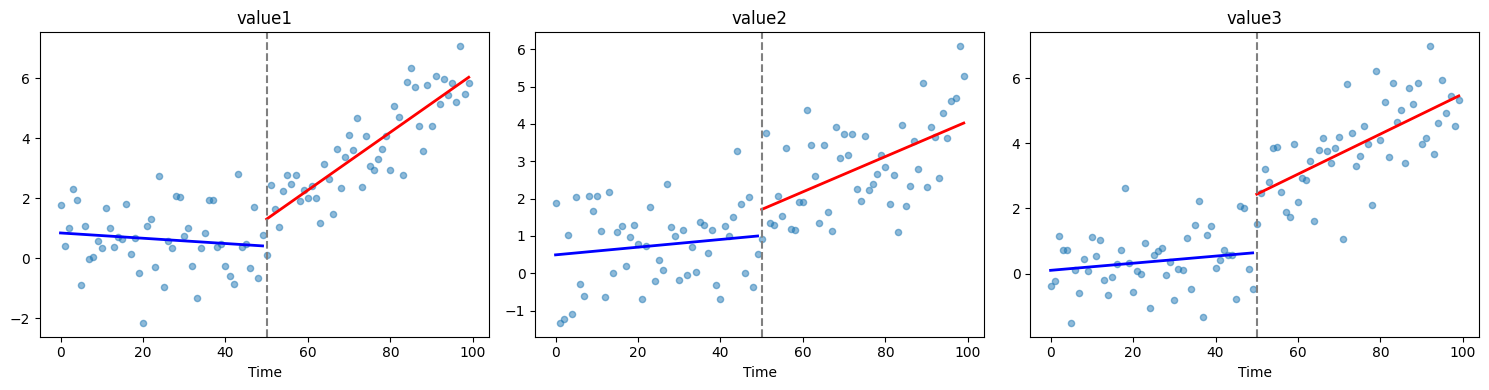

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['value1', 'value2', 'value3']):
    model = results[col]
    ax.scatter(df1['time'], df1[col], alpha=0.5, s=20)
    for mask, color in [((df1['time'] < CUTOFF), 'blue'), ((df1['time'] >= CUTOFF), 'red')]:
        subset = df1[mask].sort_values('time')
        ax.plot(subset['time'], model.fittedvalues[mask], color=color, linewidth=2)
    ax.axvline(CUTOFF, color='gray', linestyle='--')
    ax.set_title(col)
    ax.set_xlabel('Time')

plt.tight_layout()
plt.savefig('rdd_plots.png', bbox_inches='tight', dpi=150)
plt.show()

## Q3–5: Differences-in-Differences

In [4]:
did_results = {}
for name, df in [('3.2a', dfa), ('3.2b', dfb)]:
    model = smf.ols('outcome ~ group + time + group:time', data=df).fit()
    did_results[name] = model
    print(f"{name}  TE={model.params['group:time']:.4f}  "
          f"SE={model.bse['group:time']:.4f}  t={model.tvalues['group:time']:.4f}")

3.2a  TE=0.6858  SE=0.0625  t=10.9696
3.2b  TE=1.3499  SE=0.1470  t=9.1798


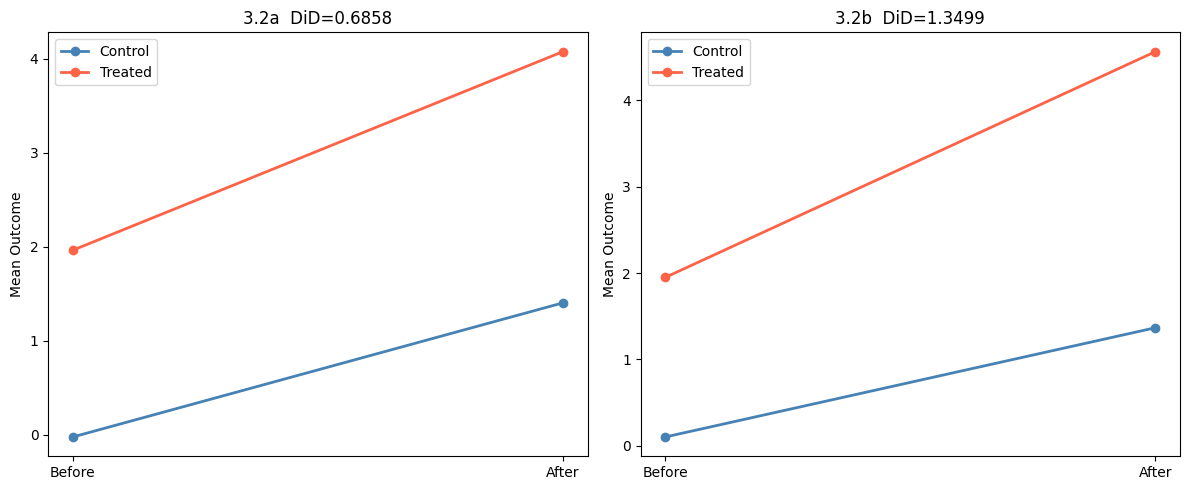

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, [('3.2a', dfa), ('3.2b', dfb)]):
    means = df.groupby(['group', 'time'])['outcome'].mean().reset_index()
    for g, color, label in [(0, 'steelblue', 'Control'), (1, 'tomato', 'Treated')]:
        subset = means[means['group'] == g].sort_values('time')
        ax.plot(subset['time'], subset['outcome'], marker='o', color=color, linewidth=2, label=label)
    te = did_results[name].params['group:time']
    ax.set_title(f'{name}  DiD={te:.4f}')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Before', 'After'])
    ax.set_ylabel('Mean Outcome')
    ax.legend()

plt.tight_layout()
plt.savefig('did_plots.png', bbox_inches='tight', dpi=150)
plt.show()